## 1. Import library dan load dataset

In [1]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Cek missing values
Sebelum klasterisasi, perlu dipastikan tidak ada data yang hilang karena K-Means tidak bisa menangani `NaN` secara langsung.

In [2]:
# cek missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 3. Statistik deskriptif data
`describe()` menampilkan ringkasan statistik (count, mean, std, min, kuartil, max) untuk setiap kolom numerik, berguna untuk memahami skala dan sebaran tiap fitur sebelum clustering.

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Dari hasil `describe()` terlihat skala antar fitur berbeda jauh: **Age** berkisar 18–70, sedangkan **Annual Income** berkisar 15–137 (dalam ribuan dolar), dan **Spending Score** 1–99. Perbedaan skala ini penting karena K-Means berbasis jarak — fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak jika tidak di-*scale*.

## 4. Mengambil subset kolom numerik (Annual Income & Spending Score)
`df.iloc[:, 3:]` mengambil kolom indeks ke-3 dan seterusnya, yaitu `Annual Income (k$)` dan `Spending Score (1-100)` — dua fitur utama yang dipakai pada analisis awal.

In [4]:
dataset = df.iloc[:,3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 5. Menentukan variabel X dan Y untuk visualisasi 2D
- `x` = kolom indeks 3 → **Annual Income (k$)**
- `y` = kolom indeks 4 → **Spending Score (1-100)**

In [5]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]

## 6. Visualisasi scatter plot awal
Plot ini menunjukkan sebaran pelanggan berdasarkan pendapatan tahunan dan skor belanja, **sebelum** dilakukan clustering. Secara visual sudah terlihat ada beberapa gerombolan (kelompok) data yang terpisah, mengindikasikan data ini cocok untuk K-Means.

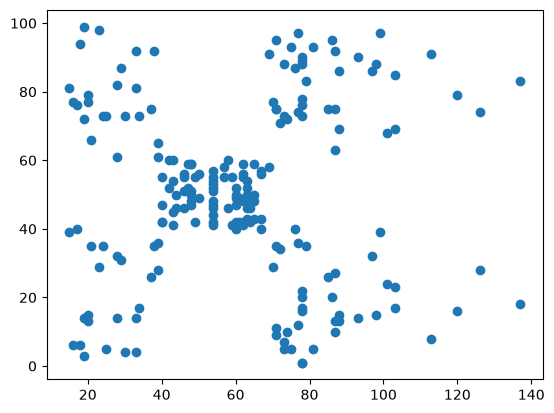

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

## 7. Scaling data dan Elbow Method (2 fitur)
- **MinMaxScaler** menyesuaikan skala semua fitur ke rentang [0, 1], agar fitur dengan nilai besar (Annual Income) tidak mendominasi fitur dengan nilai kecil (Spending Score) saat menghitung jarak.
- **Elbow Method**: K-Means dicoba untuk K = 1 sampai 10, lalu nilai `inertia_` (WCSS) dicatat dan diplot. Titik di mana grafik mulai melandai ("siku") menjadi kandidat K optimal.

c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

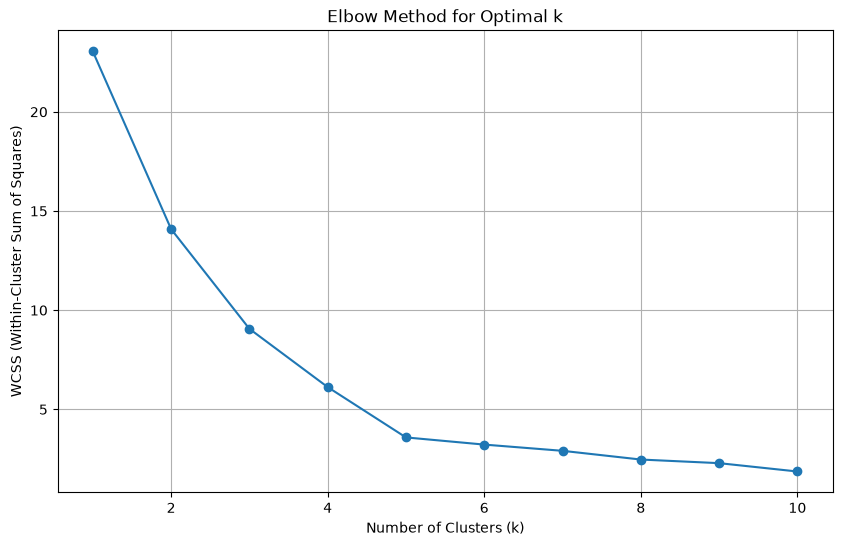

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()

# Mengambil kolom X (index 3) dan Y (index 4) dari DataFrame
X = pd.DataFrame({'Annual Income (k$)': x, 'Spending Score (1-100)': y})

X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal menggunakan Elbow Method
wcss = []
for i in range(1, 11):  # Coba k dari 1 sampai 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Membuat plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

Dari grafik Elbow, penurunan WCSS sangat tajam dari K=1 hingga K=4-5, lalu mulai melandai setelah itu. Titik siku berada sekitar **K = 5**, sehingga nilai ini dipilih sebagai jumlah klaster optimal untuk 2 fitur (Annual Income & Spending Score).

## 8. Klasterisasi dengan K = 5 (2 fitur)
Model K-Means dilatih langsung pada `X` (data belum di-scale di sel ini, mengikuti alur modul) dengan `n_clusters=5`. Hasil klaster (`kmeans.labels_`) lalu dipakai untuk mewarnai scatter plot.

c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


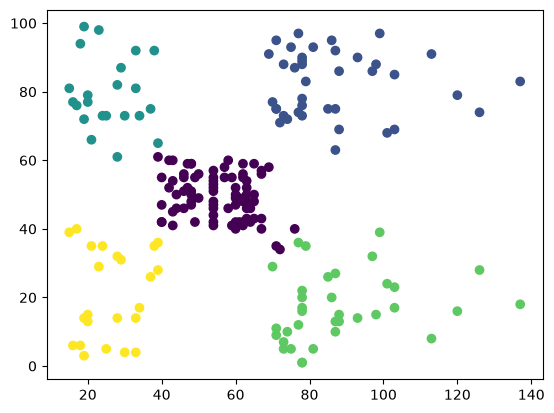

In [8]:
# dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

Dari hasil plot terlihat **5 klaster pelanggan** yang cukup jelas terpisah berdasarkan Annual Income dan Spending Score, misalnya:
- Income rendah & Spending rendah
- Income rendah & Spending tinggi
- Income menengah & Spending menengah (gerombolan besar di tengah)
- Income tinggi & Spending rendah
- Income tinggi & Spending tinggi

Pola ini berguna untuk strategi pemasaran: pelanggan "Income tinggi & Spending tinggi" adalah target promosi premium, sedangkan "Income tinggi & Spending rendah" berpotensi didekati dengan penawaran khusus agar belanjanya meningkat.

## 9. Klasterisasi dengan 3 fitur: Age, Annual Income, Spending Score
Selanjutnya analisis diperluas dengan menambahkan fitur **Age**, sehingga clustering dilakukan pada 3 dimensi sekaligus. Visualisasi 3D diperlukan agar sebaran data tetap bisa dipahami.

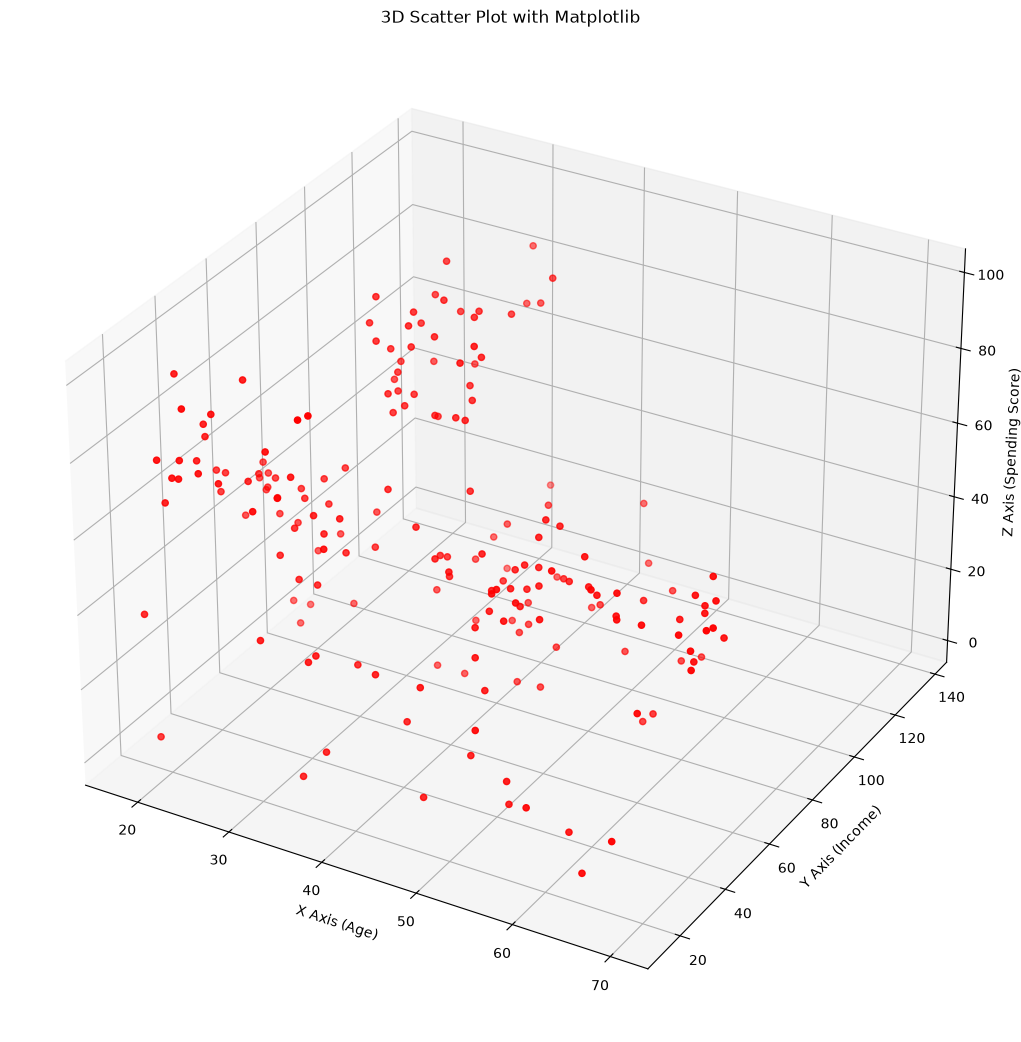

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Data Age, Annual Income, dan Spending Score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]

# Membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(x, y, z, c='red', marker='o')

# Label sumbu
ax.set_xlabel('X Axis (Age)')
ax.set_ylabel('Y Axis (Income)')
ax.set_zlabel('Z Axis (Spending Score)')

plt.title('3D Scatter Plot with Matplotlib')
plt.show()

Scatter plot 3D ini menunjukkan sebaran pelanggan di ruang Age–Income–Spending Score sebelum clustering. Belum terlihat kelompok yang jelas karena semua titik masih satu warna; langkah selanjutnya adalah mencari K optimal dan menjalankan K-Means pada ketiga fitur ini.

## 10. Scaling dan Elbow Method (3 fitur)
Sama seperti sebelumnya, data 3 fitur digabung menjadi array, di-scale dengan `MinMaxScaler`, lalu dicari K optimal memakai Elbow Method.

c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\glory\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

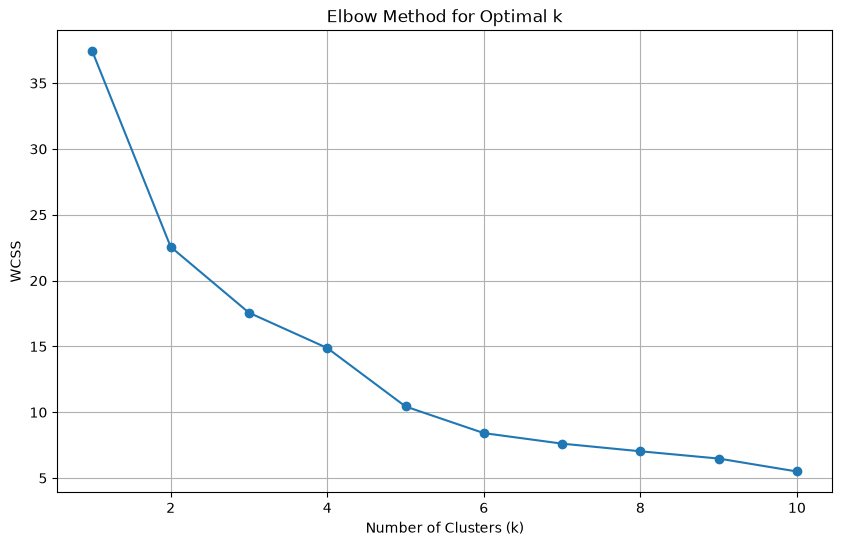

In [10]:
# Menggabungkan data X, Y, Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal dengan Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Dengan 3 fitur, penurunan WCSS melandai di sekitar **K = 5–6**. Karena titik siku kurang setajam kasus 2 fitur (penambahan dimensi membuat data lebih "menyebar"), dipilih **K = 6** agar klaster yang terbentuk lebih detail membedakan kelompok usia, income, dan spending.

## 11. Klasterisasi final dengan K = 6 (3 fitur) dan visualisasi 3D
Model K-Means final dilatih pada data **asli** (`X`, belum di-scale) dengan `n_clusters=6`. Hasil klaster disimpan ke kolom baru `Cluster` pada DataFrame, lalu divisualisasikan dalam scatter plot 3D berwarna.

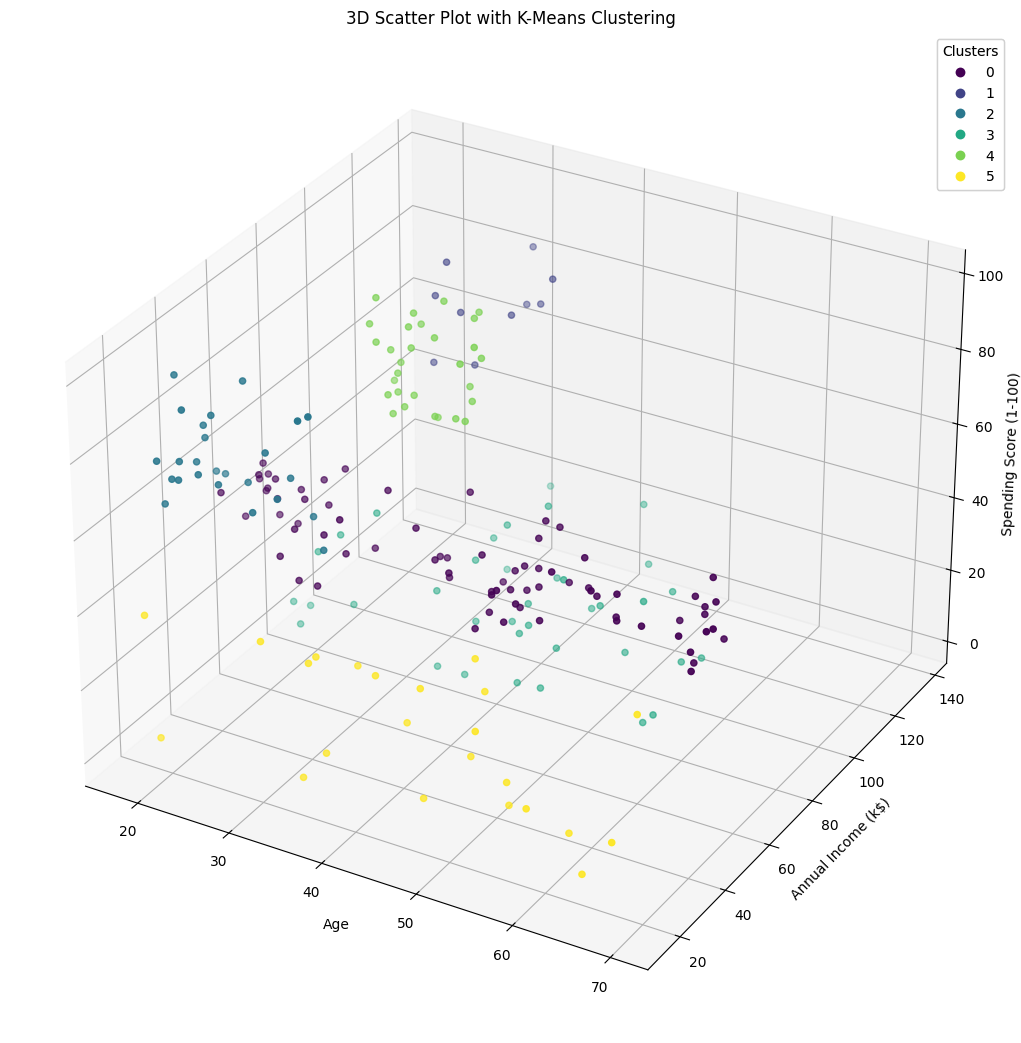

In [11]:
# Pilih k optimal setelah melihat Elbow
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)

# Menambahkan hasil klaster ke DataFrame
df['Cluster'] = clusters

# Visualisasi 3D Hasil K-Means
# Plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot setiap titik dengan warna sesuai klaster
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')

# Label sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

# Menampilkan legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.title('3D Scatter Plot with K-Means Clustering')
plt.show()

## 12. Melihat karakteristik tiap klaster
Untuk interpretasi bisnis, ditampilkan rata-rata Age, Annual Income, dan Spending Score, serta jumlah anggota tiap klaster.

In [12]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Jumlah Pelanggan'] = df['Cluster'].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Jumlah Pelanggan
Cluster,,,,
0,43.934211,55.210526,49.447368,76
1,32.200000,109.700000,82.000000,10
2,24.960000,28.040000,77.000000,25
3,40.324324,87.432432,18.189189,37
4,32.862069,78.551724,82.172414,29
5,45.217391,26.304348,20.913043,23


### Interpretasi hasil klaster
Berdasarkan tabel rata-rata di atas (hasil aktual K=6), tiap klaster dapat diberi label bisnis:

| Cluster | Rata² Age | Rata² Income (k$) | Rata² Spending | Jumlah | Interpretasi |
|---|---|---|---|---|---|
| 0 | 43.9 | 55.2 | 49.4 | 76 | **Pelanggan umum** — usia dewasa, income & spending menengah. Kelompok terbesar (mayoritas pasar). |
| 1 | 32.2 | 109.7 | 82.0 | 10 | **Premium/VIP** — income sangat tinggi, spending sangat tinggi. Target utama program loyalitas. |
| 2 | 25.0 | 28.0 | 77.0 | 25 | **Muda & impulsif** — income rendah tapi spending tinggi. Cocok untuk promo cicilan/diskon. |
| 3 | 40.3 | 87.4 | 18.2 | 37 | **Hemat berpenghasilan tinggi** — income tinggi tapi spending rendah. Berpotensi besar, perlu didekati dengan penawaran eksklusif agar belanja meningkat. |
| 4 | 32.9 | 78.6 | 82.2 | 29 | **Pelanggan ideal** — income tinggi, spending tinggi, usia relatif muda. Segmen paling menguntungkan. |
| 5 | 45.2 | 26.3 | 20.9 | 23 | **Hemat/konservatif** — income rendah, spending rendah, usia lebih tua. Potensi rendah untuk promosi mahal. |

Klaster 0 (pelanggan umum) adalah kelompok terbesar, sementara Klaster 1 (premium) paling kecil tapi paling bernilai secara nilai belanja per pelanggan.

## Kesimpulan
1. **Elbow Method** membantu menentukan jumlah klaster optimal dengan melihat titik di mana penurunan WCSS mulai melandai: **K=5** untuk 2 fitur (Annual Income, Spending Score), dan **K=6** untuk 3 fitur (ditambah Age).
2. **MinMaxScaler** penting dipakai saat mencari K optimal (Elbow Method) karena fitur-fitur punya skala berbeda jauh, namun pada pelatihan model final di modul ini K-Means langsung dipakai pada data asli (tanpa scaling) agar visualisasi sumbu tetap dalam satuan aslinya (tahun, k$, skor).
3. Hasil clustering memberikan **segmentasi pelanggan** yang berguna untuk strategi pemasaran mall, misalnya membedakan pelanggan hemat, impulsif, dan premium berdasarkan kombinasi usia, pendapatan, dan kebiasaan belanja.
4. Menambahkan fitur (dari 2 ke 3 fitur) membuat segmentasi lebih detail tetapi juga lebih sulit divisualisasikan, sehingga diperlukan plot 3D.